# Dataset description
## Real GDP per capita spend on healt
**Source**: DANE

**gdp**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/cuentas-nacionales/cuentas-nacionales-trimestrales/historicos-producto-interno-bruto-pib)

**population**: [link](https://www.dane.gov.co/index.php/estadisticas-por-tema/demografia-y-poblacion/proyecciones-de-poblacion)

# Code
## Imports

In [120]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from highlight_text import fig_text

pd.set_option('display.float_format', '{:.0f}'.format)

## Load date

In [121]:
path_pop = "./data/nacional.csv"
path_gdp = "./data/goal_homes_spend.csv"

pop = pd.read_csv(path_pop, encoding="utf-8", usecols=["AÑO", "Total"])
df = pd.read_csv(path_gdp, encoding="utf-8")

## Clean

In [122]:
df_f = df[df["Concepto"].eq("Salud")]
df_f = df_f.drop(columns=["Concepto"])
df_f.columns = df_f.columns.str.split("-", n=1).str[0]
df_f.columns = df_f.columns.str.replace("p|r", "", regex=True)

health = df_f.T.groupby(df_f.columns.astype(str)).sum()
health = health.reset_index()
health["index"] = health["index"].astype(int)
health = health[~(health["index"].eq(2026))]

buffer = pd.merge(pop, health, left_on="AÑO", right_on="index", how="inner")
buffer = buffer.rename(columns={5: "gdp"})
buffer["per_capita"] = (buffer["gdp"] / buffer["Total"]) * 1_000_000_000_000

per_capita = buffer.set_index("AÑO")["per_capita"]

to_2020 = per_capita[per_capita.index <= 2020]
after_2020 = per_capita[per_capita.index >= 2020]

## Plot

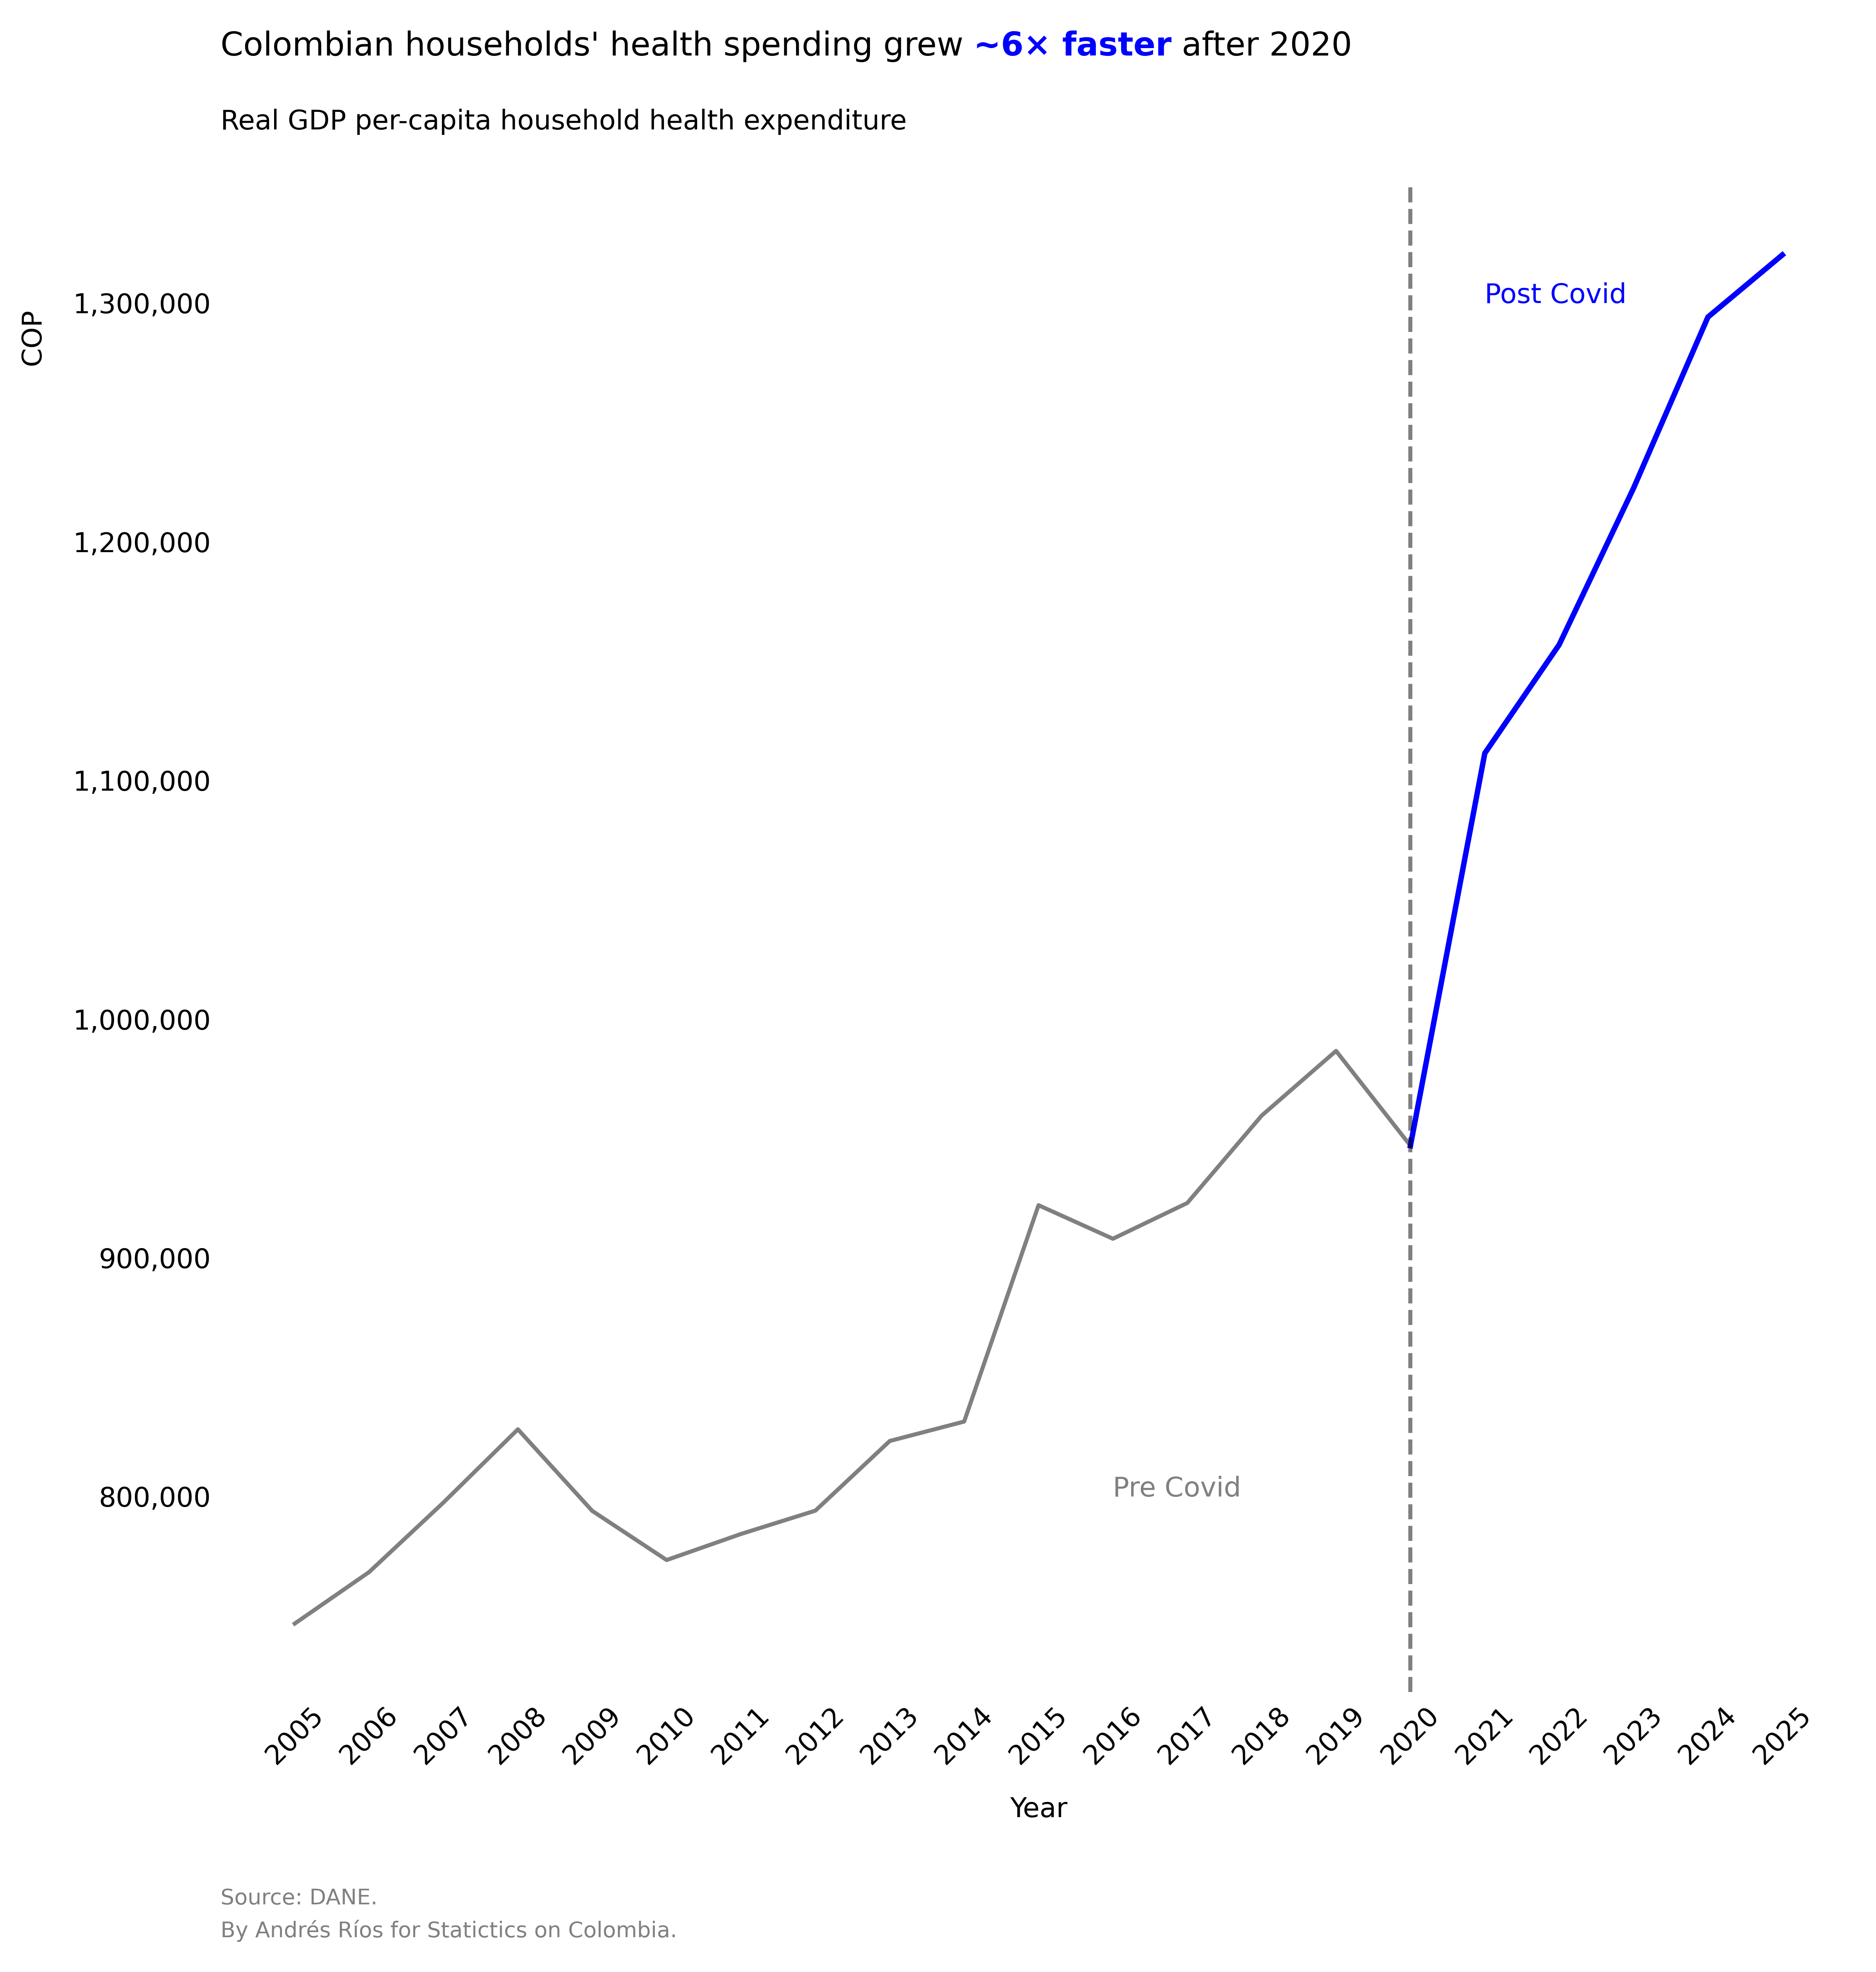

In [123]:
plt.figure(figsize=(10.8, 10), dpi=500)

plt.plot(to_2020, color="gray")
plt.plot(after_2020, color="blue", linewidth=2)

plt.xticks(per_capita.index, rotation=45)

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

plt.axvline(2020, color="black", linestyle="--", alpha=0.5)

plt.text(2021, 1300000, "Post Covid", color="blue")
plt.text(2016, 800000, "Pre Covid", color="Grey")

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

plt.ylabel("COP", labelpad=10, y=0.9)
plt.xlabel("Year", labelpad=10)

fig_text(
    0.125, 0.96,
    s="Colombian households' health spending grew <~6× faster> after 2020",
    highlight_textprops=[{"color": "blue", "weight": "bold"}],
    fontsize=12
)

fig_text(
    0.125, 0.92,
    s="Real GDP per-capita household health expenditure",
    fontsize=10
)

fig_text(
    0.125, 0.01, 
    "Source: DANE.\n"
    "By Andrés Ríos for Statictics on Colombia.", 
    fontsize=8, color="gray",
)

plt.show()